In [1]:
%load_ext autoreload
%autoreload 2
import cooler
import pandas as pd

res = 12800
# res = 12800

cool_nc18 = cooler.Cooler(f'./cools/nc1-8_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/{res}')
cool_nc14 = cooler.Cooler(f'./cools/nc14_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/{res}')
cool_s10 = cooler.Cooler(f'./cools/s10-12_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/{res}')

In [2]:
%load_ext autoreload
%autoreload
import scanpy as sc
import sys

sys.path.append('./code2')

from hic_zscore_functions import make_obs_exp_intra
from aux_functions import *
from plotting_functions import *

sc.settings.set_figure_params(dpi=80, color_map='coolwarm', frameon=True)
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({"axes.grid.axis" : 'both'})
plt.rcParams.update({"axes.grid" : True})

plt.rcParams.update({
    'axes.labelsize': 14,       # x and y labels' font size
    'xtick.labelsize': 8,      # x tick labels' font size
    'ytick.labelsize': 8,      # y tick labels' font size
    'axes.titlesize': 14,        # Axes title font size
    'patch.linewidth' : .35,
    'lines.linewidth' : .5,
    'legend.fontsize': 6,      # Legend font size
})
plt.rcParams['pdf.fonttype'] = 42

plt.rcParams.update({
    'axes.labelsize': 8,       # x and y labels' font size
    'xtick.labelsize': 6,      # x tick labels' font size
    'ytick.labelsize': 6,      # y tick labels' font size
    'axes.titlesize': 10,        # Axes title font size
    'patch.linewidth' : .35,
    'lines.linewidth' : .5,
    'xtick.major.pad' : 2,
    'ytick.major.pad' : 2,

})
plt.rcParams['axes.linewidth'] = .25
plt.rcParams['xtick.major.width'] = .25
plt.rcParams['ytick.major.width'] = .25
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['grid.linewidth'] = .25

plt.rcParams['axes.facecolor'] = 'none' # Or any suitable colour...
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'none'

plt.rcParams['axes.facecolor'] = 'none' # Or any suitable colour...
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'none'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from config import load_cses, load_loop_anchors
from config import rgb_to_cluster, cluster_to_rgb

all_cses = load_cses()
all_loop_anchors = load_loop_anchors()

In [4]:
nc14_boundaries = pd.read_csv('./annotations/nc14_1_1+1_2+2_1+2_2.boundaries_and_both_with_cluster_colors.scores=plain.bed',
                   sep = '\t', 
                              header=None
                  )

nc14_boundaries['cluster'] = nc14_boundaries[8].apply(rgb_to_cluster.get)

In [5]:
import os

import collections
def bed_to_ivt(bed_file, r):
    ivt = collections.defaultdict(intervaltree.IntervalTree)
    i = 0
    with maybe_gzip_open(bed_file, "r") as read_file:
        for line in read_file:
            line = line.strip()
            if line and not line.startswith("#"):
                line = line.split("\t")
                chrom = line[0]
                start = int(line[1])
                end = int(line[2])
                start, end = min(start, end), max(start, end)
                if r is not None:
                    mid = start + int((end - start) / 2)
                    start = mid - r
                    end = mid + r
                if end - start == 0:
                    continue
                ivt[chrom].add(intervaltree.Interval(start, end, {bed_file: [(i, chrom, int(line[1]), int(line[2]))]}))
                i += 1
    return ivt

import gzip

def maybe_gzip_open(x, mode):
    if x.endswith(".gz"):
        return gzip.open(x, mode + "t")
    else:
        return open(x, mode)

In [6]:
import pickle
def make_conservation_plot_figure_4c():
    pref = '/Genomics/function/ogtgrid/ecofer/drosophila_micro_c/'
    ordered_ivt_df = pickle.load(open(pref + '/4DN_data/browser_tracks/ordered_ivt_df.pkl', 'rb'))
    
    is_ins = ordered_ivt_df.boundary_idx.apply(lambda x: len(x) > 0).values
    is_la = ordered_ivt_df.loop_anchor_idx.apply(lambda x: len(x) > 0).values
    is_both = is_ins & is_la
    tmp = is_ins & (~is_la)
    is_la = is_la & (~is_ins)
    is_ins = tmp
    
    
    
    str_dict = dict()
    for x in ordered_ivt_df[["chrom", "start", "end", "merged_idx"]].itertuples(index=False, name=None):
        str_dict["{}:{}-{}".format(x[0], x[1], x[2])] = x
        
    # Pull in blast results.
    hits_df = list()
    for cluster in range(4):
        df = pandas.read_csv(pref + "4DN_data/merged_boundaries_clustering/all.cluster={}.blastn_output6".format(cluster),
                             sep="\t", names=["qseqid", "sseqid", "pident", "length", "mismatch", "gapopen",
                                                "qstart", "qend", "sstart", "send", "evalue", "bitscore"])
        for i in range(df.shape[0]):
            hits_df.append((df.qseqid.iloc[i],
                            cluster, 
                            df.sseqid.iloc[i], df.sstart.iloc[i], df.send.iloc[i],
                            df.length.iloc[i], df.pident.iloc[i]))
    hits_df = pandas.DataFrame(hits_df, columns=["s", "cluster", "hit_chrom", "hit_start", "hit_end", "alignment_length", "percent_identity"])
    for i, x in enumerate(["chrom", "start", "end", "merged_idx"]):
        hits_df[x] = hits_df["s"].apply(lambda x: str_dict[x][i])
    hits_df.drop("s", axis=1, inplace=True)
    hits_df['is_both'] = is_both[hits_df.merged_idx.values]
    hits_df['is_la'] = is_la[hits_df.merged_idx.values]
    hits_df['is_ins'] = is_ins[hits_df.merged_idx.values]
    hits_df['dmel_id'] = df_to_index(hits_df[['chrom', 'start', 'end']])
    
    
    
    f = 'dvir.base_resolution=100.resolution=400.window_size=16.d=3.boundaries.cutoff=1.00e+00.blacklist=coverage.bed.gz'
    f = os.path.join(pref + "dvir_data/merged_boundaries/", f)
    
    # Read in strengths
    dvir_df = pandas.read_csv(f, sep="\t", names=["chrom", "start", "end", "x1", "score", "x2"])
    dvir_df.drop(["x1", "x2"], axis=1, inplace=True)

    # Read in IVt.
    dvir_ivt = bed_to_ivt(f, None)
    dvir_ivt_k = f
    print("Finished")
    
    
    
    # Recover boundaries.
    r = 1_000
    cur = hits_df.copy()
    cur = cur[cur.is_ins.values | cur.is_both.values]
    fnd = list()
    for x, df in hits_df.groupby("dmel_id"):
        chrom = df.chrom.iloc[0]
        start = df.start.iloc[0]
        end = df.end.iloc[0]
        for i in range(df.shape[0]):
            hchrom = df.hit_chrom.iloc[i]
            hstart = df.hit_start.iloc[i]
            hend = df.hit_end.iloc[i]
            hstart, hend = min(hstart, hend), max(hstart, hend)
    #         hmid = hstart + int((hend - hstart) / 2)
            for hit in dvir_ivt[hchrom][hstart-r:hend+r]:
                if len(hit.data[dvir_ivt_k]) > 1:
                    msg = str(hit)
                    raise ValueError(msg)
                hit = hit.data[dvir_ivt_k][0]
                dvir_idx = hit[0]
                assert hit[1] == dvir_df.chrom.iloc[dvir_idx]
                assert hit[2] == dvir_df.start.iloc[dvir_idx]
                assert hit[3] == dvir_df.end.iloc[dvir_idx]
                fnd.append((x, dvir_df.score.iloc[dvir_idx]))
    fnd = pandas.DataFrame(fnd, columns=["merged_idx", "score"])
    fnd = fnd.set_index('merged_idx')
    
    
    
    all_cses_dvir = pd.concat([all_cses, fnd.iloc[~fnd.index.duplicated()]], axis=1).dropna()
    
    
    dfs = []
    for cluster, df in all_cses_dvir.groupby("cluster"):
        n_conserved_fn = len(set(df.index.tolist()))
        xx = hits_df[hits_df[['is_both', 'is_ins']].any(axis=1) & (hits_df.cluster == cluster)]
        xx = xx[xx['percent_identity'] > .85].drop_duplicates('merged_idx')
        n_cons_seq_only = len(xx) - n_conserved_fn
        n_not = nc14_boundaries['cluster'].value_counts()[cluster] - n_cons_seq_only - n_conserved_fn
    
        df = pandas.DataFrame([("Functional conservation", n_conserved_fn),
                               ("Sequence-only conservation", n_cons_seq_only), 
                               ("Not conserved", n_not)], columns=["variable", "value"])
        
        df["cluster"] = cluster
        dfs.append(df)
        
    pivot_df = pd.concat(dfs, axis=0).pivot(index='variable', columns='cluster', values='value')
    
    baseline = pivot_df.sum(axis=1)
    pval_df = pd.DataFrame()
    for col in pivot_df:
        vals = pivot_df[col]
        ps = []
        for i in pivot_df.index:
            inside = vals[i]
            outside = vals.drop(i).sum()
    
            baseline_inside = baseline[i]
            baseline_outside = baseline.drop(i).sum()
    
            v = [[inside, outside], [baseline_inside, baseline_outside]]
            _, p = scipy.stats.fisher_exact(v, alternative='greater')
            ps.append(p)
        pval_df[col] = ps
    
    pval_df = pval_df.T
    pval_df.index = pivot_df.columns
    pval_df.columns = pivot_df.index
    
    freq_df = (pivot_df / pivot_df.sum(axis=0)).T
    freq_df.index = ['Cluster ' + str(x) for x in freq_df.index]
    freq_df = freq_df[['Not conserved', 'Sequence-only conservation', 'Functional conservation']]
    fig, axs = init_subplots_exact(1, 1, fgsz=(40*mm, 40*mm), dpi = 150)
    freq_df.plot.bar(stacked = True, color=['lightgray', 'pink', 'purple'], ax = axs,
                        linewidth = .25,
                        edgecolor = 'black',
                    )
    plt.xticks(rotation=20)
    axs.spines['top'].set_visible(False)
    axs.spines['right'].set_visible(False)
    plt.legend(bbox_to_anchor = (1, 1), frameon = False)
    plt.xlabel("Cluster")
    plt.ylabel("Proportion")
    
    size = .05
    for u in [0, 1, 2, 3]:
        d = np.abs(arr(axs.get_xlim())).sum()*size
        rec = mpl.patches.Rectangle((u - d/2, -.22), d, size, color=None, facecolor=cluster_to_rgb[u], clip_on=False)
        axs.add_patch(rec)
    
    
    size = .05
    for u in [0, 1, 2, 3]:
        
        for c, col in enumerate(freq_df.columns):
            p = pval_df.loc[u, col]
            if (abs(p) < .05):# & (p > 0):
                if c == 0:
                    base = 0
                else:
                    base = freq_df.loc['Cluster ' + str(u)].cumsum()[c-1]# - df.loc['Cluster ' + str(u)].cumsum()[0]
                y = base + freq_df.loc['Cluster ' + str(u)][col]/2
                plt.text(u + .3, y, '*', va='center', fontsize=8, ha='left')
                if y > 1:
                    raise Exception
        d = np.abs(arr(axs.get_xlim())).sum()*size
        rec = mpl.patches.Rectangle((u - d/2, -.22), d, size, color=None, facecolor=cluster_to_rgb[u], clip_on=False,
                                   )
        axs.add_patch(rec)
    
    plt.grid(False)
    plt.xlabel("")
    fig.savefig('./new_figures/fig4/conservation_4c.pdf', bbox_inches='tight')    

Finished


/tmp/ipykernel_2904682/2336127305.py:157: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  base = freq_df.loc['Cluster ' + str(u)].cumsum()[c-1]# - df.loc['Cluster ' + str(u)].cumsum()[0]


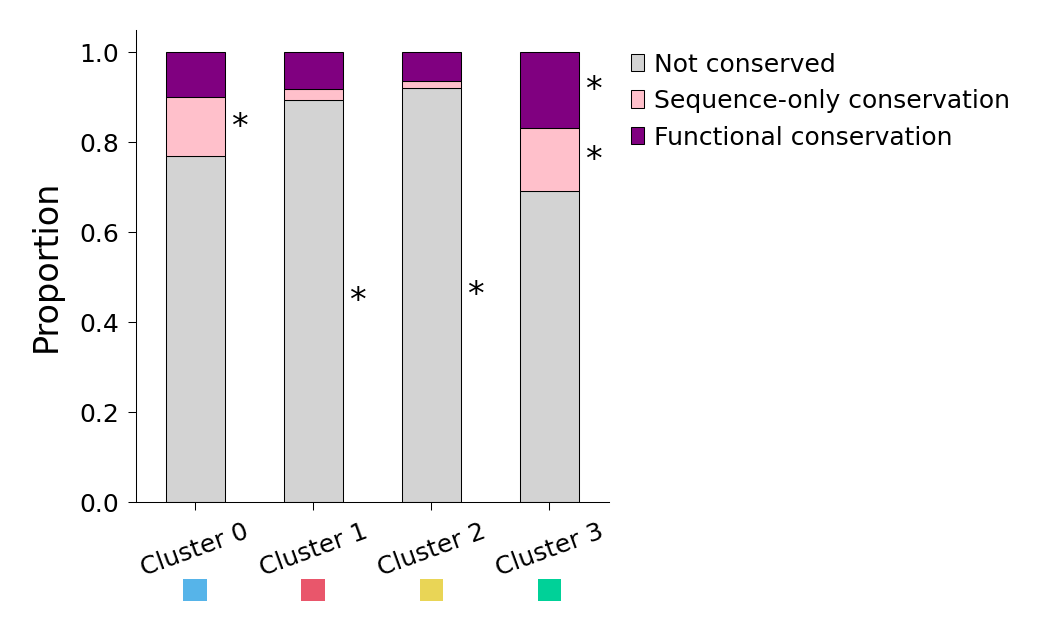

In [7]:
make_conservation_plot_figure_4c()

In [8]:
def compute_motif_looping(motif_conservation):
    motif_df = pd.read_csv('./intermediate_files/cses_with_motif.csv', sep='\t', index_col = 0)
    result = aggregate_df_by_others(all_cses, motif_df, 'has_loop')
    result[0] = result[0].str.replace('vfl', 'Zld')
    
    motif_looping = result.sort_values(1).set_index(0)[1].loc[motif_conservation.index]
    return motif_looping

def aggregate_df_by_others(value_df, index_df, col):
    results = [] 
    for index_col in index_df:
        idx = index_df.index[index_df[index_col] > 0]
        results.append([index_col, value_df.loc[idx, col].mean()])
    return pd.DataFrame(results)

def compute_motif_conservation(atac_peak_motifs, atac_conservation):
    results = []
    for u in atac_peak_motifs:
        idx = atac_peak_motifs.index[atac_peak_motifs[u]>0]
        vals = atac_conservation.loc[idx]['phyloP27'].reset_index()
        vals['factor'] = u
        results.append(vals)
    conservation_by_motif = pd.concat(results, axis=0)
    conservation_by_motif['factor'] = conservation_by_motif['factor'].str.replace('vfl', 'Zld')
    motif_conservation = conservation_by_motif.groupby('factor')['phyloP27'].mean()
    return motif_conservation, conservation_by_motif


In [9]:
from aux_functions import *
import bbi
def make_conservation_dfs():
    lfc_df = pd.read_csv('/Genomics/argo/users/gdolsten/pritlab/snakemake_sras/differential/24_blythe_ATAC_lfcs/atac_peaks.tsv', sep = '\t')
    lfc_df.index = df_to_index(lfc_df)
    atac_conservation = pd.DataFrame()
    atac_peaks = index_to_bedtool(lfc_df.index).to_dataframe()
    phylop_bw = bbi.open('intermediate_files/dm6.phyloP27way.bw')
    atac_conservation['phyloP27']  = phylop_bw.stackup(atac_peaks['chrom'], atac_peaks['start'], atac_peaks['end'], bins=1).flatten()
    atac_conservation.index = lfc_df.index.str.replace('chr', '')
    
    atac_in_CSE = index_to_bedtool(atac_conservation.index).intersect(index_to_bedtool(all_cses.index), c=True).to_dataframe().iloc[:, -1].values>0
    atac_conservation = atac_conservation[atac_in_CSE]
    
    atac_summit_motifs = pd.read_csv('/Genomics/argo/users/gdolsten/pritlab/jupys/tregs/rudensky_scrna/prelim-analysis/meme/fimo_output/dm6_atac_atlas.bed', sep='\t')
    atac_summit_motifs['chr'] = atac_summit_motifs['chr'].str.replace("CHR", "chr")
    atac_summit_motif_bed = remove_chr_bedtool(pbt.BedTool.from_dataframe(atac_summit_motifs))
    
    results = []
    for i in atac_summit_motif_bed.intersect(index_to_bedtool(atac_conservation.index), wo=True):
        motif_info = i[5]
        cse_info = '_'.join(i[13:13+3])
        results.append([cse_info, motif_info])
    
    atac_peak_motifs = pd.DataFrame(results).value_counts().unstack().fillna(0)
    
    same = atac_peak_motifs.index.intersection(atac_conservation.index)
    atac_conservation = atac_conservation.loc[same]
    atac_peak_motifs = atac_peak_motifs.loc[same]
    motif_conservation, conservation_by_motif = compute_motif_conservation(atac_peak_motifs, atac_conservation)
    motif_looping = compute_motif_looping(motif_conservation)
    return atac_peak_motifs, motif_conservation, motif_looping

In [10]:
atac_peak_motifs, motif_conservation, motif_looping = make_conservation_dfs()

In [11]:
from adjustText import adjust_text
def label_points(x, y, indices, labels, fontsize=6, textcolor='black', s=4, ha='right',edgecolor = 'black',  linewidth = .2, bold=True):
    texts = []
    for c, i in enumerate(indices):
        gene_name = labels[c]
        plt.scatter(x[i], y[i], zorder = 3.6, color = 'none', edgecolor = edgecolor, linewidth = linewidth, s = s)
        if bold:
            pe=[pathe.withStroke(linewidth = .25, foreground="black")]
        else:
            pe = []
        texts.append(plt.text(x[i], y[i], gene_name, fontsize=fontsize, color = textcolor, 
                             path_effects=pe, zorder = 4,
                             ha='left',
                             ma = 'left',
                              
                             ))
    adjust_text(texts, ax=plt.gca(), arrowprops=dict(arrowstyle="-", color='black', lw=0.15, alpha=.8), zorder=3.5)

In [12]:
import numpy as np

def make_r14d():
    fig, axs = init_subplots_exact(1, 1, fgsz=(1.5, 1.5), dpi=150)
    ax = plt.gca()

    # Scatter plot with Pearson correlation
    scatter_with_pearson(motif_conservation, motif_looping, ax, s=8)

    # Line of best fit
    x = motif_conservation.values
    y = motif_looping.values
    coeffs =  scipy.stats.linregress(x, y)
    slope, intercept, _, _, _, = coeffs
    x = np.linspace(.55, 1.2, )
    ax.plot(x, x*slope + intercept, color='black', linewidth=1, linestyle='--')

    # Label specific points
    points_to_label = pd.Series(['Zld', 'Trl', 'BEAF-32'])
    label_points(motif_conservation, motif_looping, points_to_label, points_to_label, bold=False, s=8)

    plt.xlabel("Motif Conservation")
    plt.ylabel("Motif Looping")

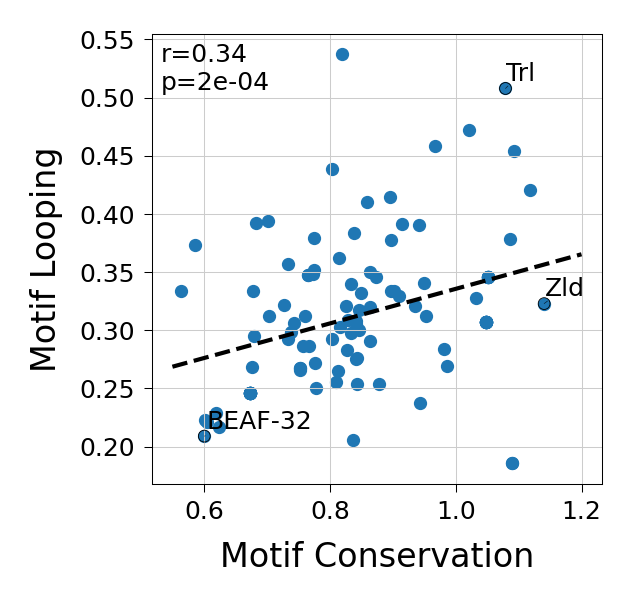

In [13]:
make_r14d()